# Calibration Study — Breast Cancer Wisconsin (Diagnostic)

**Assignment 2 — Calibration of Probabilities** (SML, Univ. of Milan)
Reference: Niculescu-Mizil & Caruana, *"Predicting Good Probabilities with Supervised Learning"*, ICML 2005.

## Why this dataset
569 samples, 30 real-valued features, binary target (1 = malignant, ~37% positive rate).
Classes are **well separated** — a linear model already reaches ~97% test accuracy — which makes this
a good "easy problem" reference point: we expect both base classifiers to start out already fairly
well-calibrated here, and we want to see whether Platt scaling / isotonic regression still help (or
whether they can even hurt, e.g. by overfitting a small calibration set).

All heavy-lifting code (dataset loading, splitting, calibration algorithms, metrics, plotting) lives in
`src/*.py` and is only *called* from this notebook — see the course rule about keeping reusable code in
`.py` modules.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.calibration import PlattScaling, IsotonicRegressionPAVA
from src.metrics import evaluate_probs
from src.plotting import plot_reliability_comparison
from src.experiment import train_base_models, SEED


In [2]:
from src.datasets import load_breast_cancer_dataset, split_train_calib_test
from sklearn.preprocessing import StandardScaler

X, y, name, description = load_breast_cancer_dataset()
print(description)

splits = split_train_calib_test(X, y, seed=SEED)
X_train, y_train = splits["X_train"], splits["y_train"]
X_calib, y_calib = splits["X_calib"], splits["y_calib"]
X_test, y_test = splits["X_test"], splits["y_test"]

scaler = StandardScaler().fit(X_train)
X_train, X_calib, X_test = scaler.transform(X_train), scaler.transform(X_calib), scaler.transform(X_test)

print(f"train={len(y_train)}  calib={len(y_calib)}  test={len(y_test)}")
print(f"positive rate  train={y_train.mean():.3f}  calib={y_calib.mean():.3f}  test={y_test.mean():.3f}")


Breast Cancer Wisconsin (Diagnostic): 569 samples, 30 features, binary (1=malignant), ~37% positive rate, well-separated classes.
train=341  calib=114  test=114
positive rate  train=0.372  calib=0.377  test=0.368


## Train the two base classifiers
Logistic Regression and Random Forest are used **off-the-shelf** (scikit-learn) — the assignment
explicitly whitelists these two. Everything downstream (Platt scaling, isotonic regression) is
implemented from scratch in `src/calibration.py`.

In [3]:
models = train_base_models(X_train, y_train, seed=SEED)
models


{'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
 'RandomForest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)}

## Calibrate and evaluate
For each model:
1. Take its raw `predict_proba` on the **calibration** set and fit Platt scaling / isotonic regression
   on `(raw_prob_calib, y_calib)` — never on the test set.
2. Apply the fitted calibrators to the **test** set raw probabilities.
3. Compute Accuracy / Log-loss / Brier score / ECE for Uncalibrated vs. Platt vs. Isotonic on the test set.
4. Plot the reliability diagram (all three curves overlaid, with a histogram of predicted-probability
   counts underneath).

In [4]:
results = []
prob_variants_by_model = {}

for model_name, model in models.items():
    p_calib_raw = model.predict_proba(X_calib)[:, 1]
    p_test_raw = model.predict_proba(X_test)[:, 1]

    platt = PlattScaling().fit(p_calib_raw, y_calib)
    p_test_platt = platt.predict(p_test_raw)

    isotonic = IsotonicRegressionPAVA().fit(p_calib_raw, y_calib)
    p_test_iso = isotonic.predict(p_test_raw)

    prob_variants = {"Uncalibrated": p_test_raw, "Platt": p_test_platt, "Isotonic": p_test_iso}
    prob_variants_by_model[model_name] = prob_variants

    for method_name, p in prob_variants.items():
        m = evaluate_probs(y_test, p)
        results.append({"model": model_name, "method": method_name, **m})

df_bc = pd.DataFrame(results)
df_bc


,model,method,accuracy,log_loss,brier_score,ece,tilt
0,LogisticRegression,Uncalibrated,0.964912,0.086141,0.023921,0.022014,0.018844
1,LogisticRegression,Platt,0.973684,0.088540,0.022557,0.038137,0.023848
2,LogisticRegression,Isotonic,0.973684,0.619640,0.023018,0.024474,-0.048911
3,RandomForest,Uncalibrated,0.982456,0.117687,0.029569,0.067193,0.148259
4,RandomForest,Platt,0.982456,0.094731,0.019324,0.046806,0.093037
5,RandomForest,Isotonic,0.973684,0.360608,0.027503,0.044083,0.022111


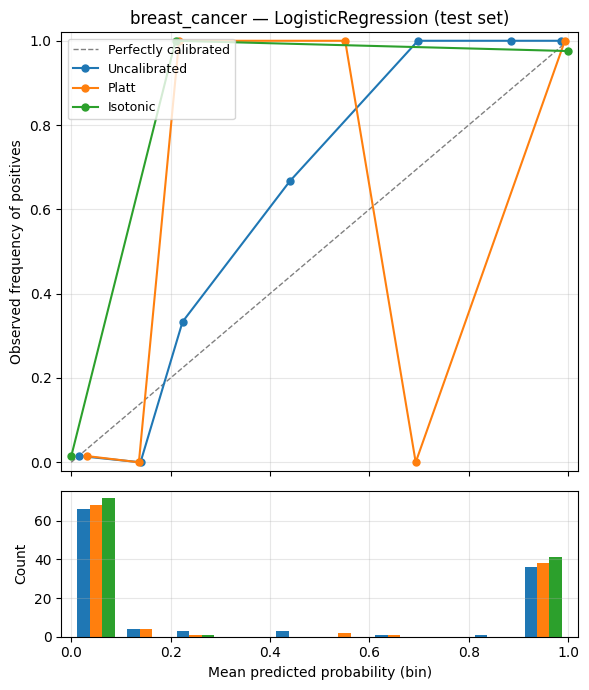

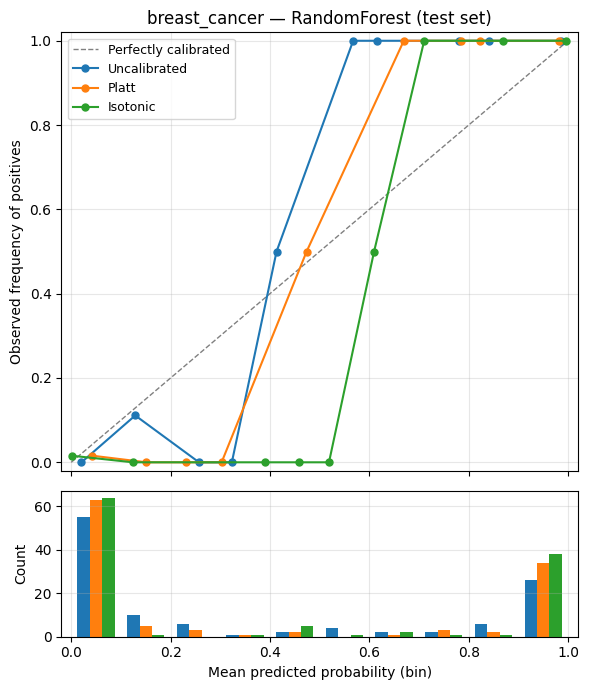

In [5]:
for model_name, prob_variants in prob_variants_by_model.items():
    plot_reliability_comparison(y_test, prob_variants, title=f"breast_cancer — {model_name} (test set)")
    plt.show()


## What to notice
- Both models start out fairly close to the diagonal already (this is the "easy" dataset), so absolute
  gains from calibration are small in Brier score / accuracy terms.
- **Isotonic regression's calibration set here (114 points) turns out to be *perfectly* rank-separated
  by both base models** — PAVA finds zero violations to pool, so it just memorizes the calibration
  labels as a hard 0/1 step function. Any test point that lands in one of those degenerate blocks and
  turns out to be misclassified gets an (eps-clipped) *huge* log-loss penalty, even though it barely
  moves the Brier score or accuracy. This is a real, well-known isotonic-regression failure mode with
  small/well-separated calibration sets (see the extended docstring in `src/calibration.py`), and a
  good discussion point for the report/oral exam: Platt scaling's Bayesian-smoothed targets are immune
  to this exact failure mode by construction.
- Random Forest's raw probabilities are visibly pulled toward 0.5 relative to Logistic Regression's —
  consistent with Niculescu-Mizil & Caruana's observation that averaging many trees washes out
  extreme confidence.